In [37]:
import xgi
import numpy as np
from tqdm import tqdm
import pickle
from multiprocess import Pool
from had_model import HAD_model
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib as mpl
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Geneva'
dpi=150

# 1) Uniform ER 

## 1.1) Results as a function of $\epsilon$

- number of connected components
- size of the largest connected component
- size of the second largest connected component
- number of hyperedges
- average hyperedge size
- max hyperedge size

    
Results averaged over 20 iterations, $\langle k \rangle = 10$ 
for the starting uniform Erdos-Renyi hypergraphs.

In [3]:
epsilons = np.linspace(0., 0.4, num=17)[1:]
cond = 'std'   # condition for agreement
Ms = [2, 4, 6]
Ns = [500, 1000, 2000, 5000]
k_avg = 10
iterations = 20    # number of iterations for each epsilon

# auxiliary functions to parallelize computations
def get_results(M):
    
    ncc = dict()
    scc1 = dict()
    scc2 = dict()
    nhe = dict()
    s_avg = dict()
    s_max = dict()
    
    for N in Ns:
        
        # All below quantities are computed at the steady state, as a function of epsilon, averaged over 'iterations'
        ncc[N] = []      # number of connected components
        scc1[N] = []     # size of the largest connected component
        scc2[N] = []     # size of the second largest connected component
        nhe[N] = []      # number of hyperedges
        s_avg[N] = []    # average hyperedge size
        s_max[N] = []    # max hyperedge size
                      
        for eps in tqdm(epsilons):
        
            ncc_it = []
            scc1_it, scc2_it = [], []
            nhe_it = []
            s_avg_it, s_max_it = [], []
            
            for it in range(iterations):
                
                H = xgi.uniform_erdos_renyi_hypergraph(N, M, k_avg, p_type="degree")
                H.cleanup()
                groups_0 = H.edges.members()
                
                Model = HAD_model(eps, groups_0)
                results = Model.simulate(condition=cond)
                opinions = results['opinions']
                groups = results['groups']
                
                # number of connected components and size of the two largest
                hedges = groups[-1]
                h = xgi.Hypergraph(hedges)
                # list of connected components
                cc = [j for j in xgi.connected_components(h)]
                ncc_it.append( len(cc) )                    
                scc = set([len(i) for i in cc])
                scc1_it.append( max(scc) / N )
                scc.remove(max(scc))
                if scc:
                    scc2_it.append( max(scc) / N )
                else:
                    scc2_it.append(0)
        
                # relative number of hyperedges
                nhe_it.append( len(groups[-1]) / len(groups_0) )
                
                # relative avg and std of hyperedge sizes
                sizes_end_it = [len(e) for e in groups[-1]]
                s_avg_it.append( np.mean(sizes_end_it) )
                s_max_it.append( np.max(sizes_end_it) )
                
            ncc[N].append(np.mean(ncc_it))
            scc1[N].append(np.mean(scc1_it))
            scc2[N].append(np.mean(scc2_it))
            nhe[N].append(np.mean(nhe_it))
            s_avg[N].append(np.mean(s_avg_it))
            s_max[N].append(np.mean(s_max_it))

    results = {
        'epsilons': epsilons,
        'ncc': ncc,
        'scc1': scc1,
        'scc2': scc2,
        'nhe': nhe,
        's_avg': s_avg,
        's_max': s_max
        }
    
    return results

In [5]:
p = Pool(processes=6)
results = p.map(get_results, Ms)

# save results
for i in range(len(Ms)):
    with open(f'../results/ER_M{Ms[i]}_{cond}.pkl', 'wb') as fp:
            pickle.dump(results[i], fp)

100%|█████████████████████████████████████████| 8/8 [2:40:16<00:00, 1202.05s/it]


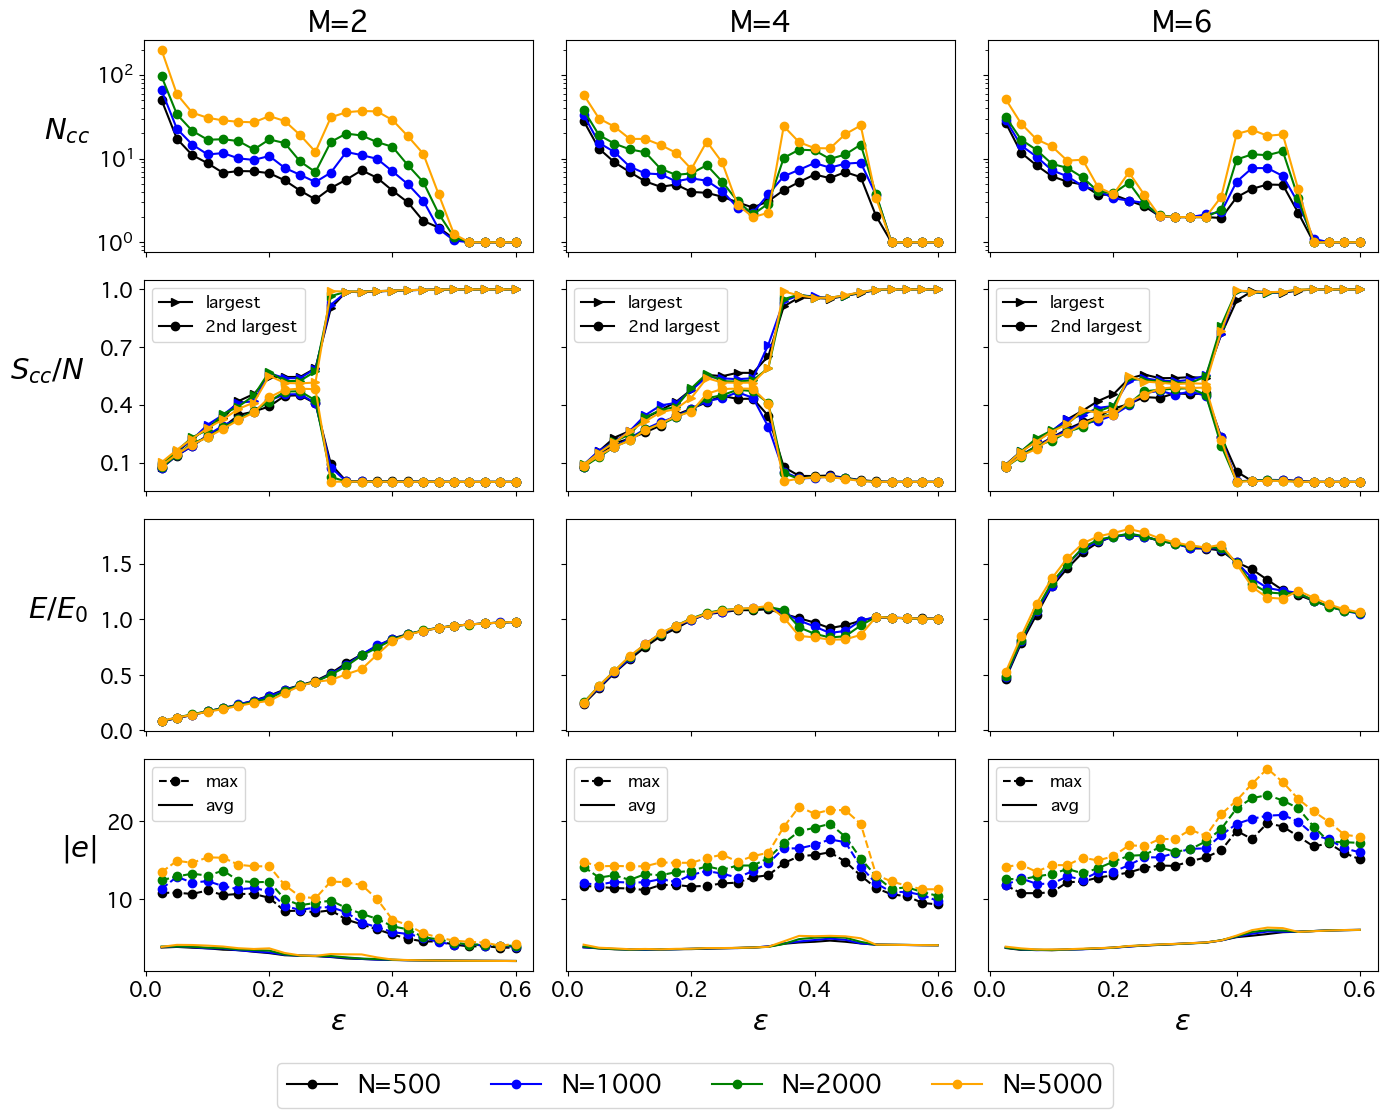

In [138]:
cond = 'max_min' 
Ns = [500, 1000, 2000, 5000]
Ms = [2, 4, 6]

nrows, ncols = 4, len(Ms)
fig, axs = plt.subplots(nrows, ncols, sharex=True, sharey='row', figsize=(14, 4*len(Ms)))
ttl_size = 21
lgd_size = 12
tick_size = 15
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N

for M in Ms:

    with open(f'../results/ER_M{M}_{cond}.pkl', 'rb') as f:
        results = pickle.load(f)
        
    epsilons = results['epsilons']
    ncc = results['ncc']
    scc1 = results['scc1']
    scc2 = results['scc2']
    nhe = results['nhe']
    s_avg = results['s_avg']
    s_max = results['s_max']

    lbls = ['largest', '2nd largest', 'avg', 'max']
    for N,clr in zip(Ns, colors):
                                   
        i = Ms.index(M)
        y0 = ncc[N]
        y1 = scc1[N]
        y2 = scc2[N]
        y3 = nhe[N]
        y4 = s_avg[N]
        y5 = s_max[N]
        
        axs[0,i].plot(epsilons, y0, color=clr, marker='o', label=f'N={N}')
        axs[0,i].set_yscale('log')

        la0 = lbls[0] if N==Ns[0] else None
        la1 = lbls[1] if N==Ns[0] else None
        axs[1,i].plot(epsilons, y1, color=clr, linestyle='-', marker='>', label=la0)
        axs[1,i].plot(epsilons, y2, color=clr, linestyle='-', marker='o', label=la1)
        tk = [0.1,0.4,0.7,1.0]
        axs[1,i].set_yticks(tk, [str(i) for i in tk])
        axs[1,i].legend(fontsize=lgd_size, loc=2)
        
        axs[2,i].plot(epsilons, y3, color=clr, marker='o', label=f'N={N}')

        la2 = lbls[2] if N==Ns[0] else None
        la3 = lbls[3] if N==Ns[0] else None
        axs[3,i].plot(epsilons, y5, label=la3, linestyle='--', marker='o', color=clr)
        axs[3,i].plot(epsilons, y4, label=la2, color=clr)
        axs[3,i].legend(fontsize=lgd_size, loc=2)

        # set tick fontsize in all subplots
        for j in range(4):
            axs[j,i].tick_params(labelsize=tick_size)

    axs[0,i].set_title(f'M={M}', fontsize=ttl_size)

axs[0,0].set_ylabel(r'$N_{cc}$', rotation=0, fontsize=ttl_size, labelpad=20)
axs[1,0].set_ylabel(r'$S_{cc}/N$', rotation=0, fontsize=ttl_size, labelpad=38)
axs[2,0].set_ylabel(r'$E/E_0$', rotation=0, fontsize=ttl_size, labelpad=30)
axs[3,0].set_ylabel(r'$|e|$', rotation=0, fontsize=ttl_size, labelpad=20)

for j in range(ncol-1):
    axs[-1, j].set_xlabel(r'$\epsilon$', fontsize=ttl_size)

# Global legend below plot, centered
legend_labels = [f'N={N}' for N in Ns]
fig.legend(labels=legend_labels, loc='lower center', bbox_to_anchor=(0.5, 0.002), fontsize=18, ncol=len(Ns))

plt.tight_layout(rect=[0, 0.06, 1, 0.94])
plt.savefig(f'../figures/ER_{cond}.jpg', dpi=dpi)
plt.show()

## 1.2) Various distributions for $\epsilon=0.1$

- distribution of sizes of connected components
- distribution of sizes of hypredges
- distribution of hyperedgrees

Results averaged over 50 iterations, $\langle k \rangle = 10$ 
for the starting uniform Erdos-Renyi hypergraphs.

In [4]:
epsilon = 0.1
cond = 'std'   # condition for agreement
Ms = [2, 4, 6]
Ns = [500, 1000, 2000, 5000]
k_avg = 10
iterations = 50    # number of iterations

# auxiliary functions to parallelize computations
def get_distributions(M):
    
    sizes_cc = dict()
    sizes_he = dict()
    sizes_hd = dict()
    
    for N in tqdm(Ns):
        
        counts_cc = dict()
        counts_he = dict()
        counts_hd = dict()
        
        for it in range(iterations):
            H = xgi.uniform_erdos_renyi_hypergraph(N, M, k_avg, p_type="degree")
            H.cleanup()
            groups_0 = H.edges.members()
            
            Model = HAD_model(epsilon, groups_0)
            results = Model.simulate(condition=cond)
            groups = results['groups']
            # hyperedges at the end of the simulation
            hedges = groups[-1]
            h = xgi.Hypergraph(hedges)
            
            # sizes of connected components
            scc = [len(i) for i in xgi.connected_components(h)]
            for s in sorted(scc):
                if s in counts_cc.keys():
                    counts_cc[s]+=1
                else:
                    counts_cc[s]=1

            # sizes of hyperedges
            she = [len(i) for i in h.edges.members()]
            for s in sorted(she):
                if s in counts_he.keys():
                    counts_he[s]+=1
                else:
                    counts_he[s]=1

            # hyperdegrees
            hds = h.nodes.degree.aslist()
            for deg in sorted(hds):
                if deg in counts_hd.keys():
                    counts_hd[deg]+=1
                else:
                    counts_hd[deg]=1
            
        sizes_cc[N] = {s: c/iterations for s,c in counts_cc.items()}
        sizes_he[N] = {s: c/iterations for s,c in counts_he.items()}
        sizes_hd[N] = {d: c/iterations for d,c in counts_hd.items()}

    results = {
        'epsilon': epsilon,
        'n_iterations': iterations,
        'k_avg': k_avg,
        'sizes_cc': sizes_cc,
        'sizes_he': sizes_he,
        'sizes_hd': sizes_hd
        }
    
    return results

In [6]:
p = Pool(processes=6)
results = p.map(get_distributions, Ms)

# save results
for i in range(len(Ms)):
    with open(f'../results/ER_M{Ms[i]}_{cond}_distributions_eps_{epsilon}.pkl', 'wb') as fp:
            pickle.dump(results[i], fp)

100%|█████████████████████████████████████████| 4/4 [4:18:45<00:00, 3881.42s/it]


M=2, N=500 ---> <k> = 3.0671626865074604
M=2, N=1000 ---> <k> = 3.1815836316726336
M=2, N=2000 ---> <k> = 3.28035
M=2, N=5000 ---> <k> = 3.338097466729068
M=4, N=500 ---> <k> = 5.590223608944358
M=4, N=1000 ---> <k> = 5.768190727629106
M=4, N=2000 ---> <k> = 5.845733829353172
M=4, N=5000 ---> <k> = 5.9298969154642815
M=6, N=500 ---> <k> = 7.310089614338294
M=6, N=1000 ---> <k> = 7.506330126602532
M=6, N=2000 ---> <k> = 7.602392167451723
M=6, N=5000 ---> <k> = 6.959184489946148


/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_2484/3795115670.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


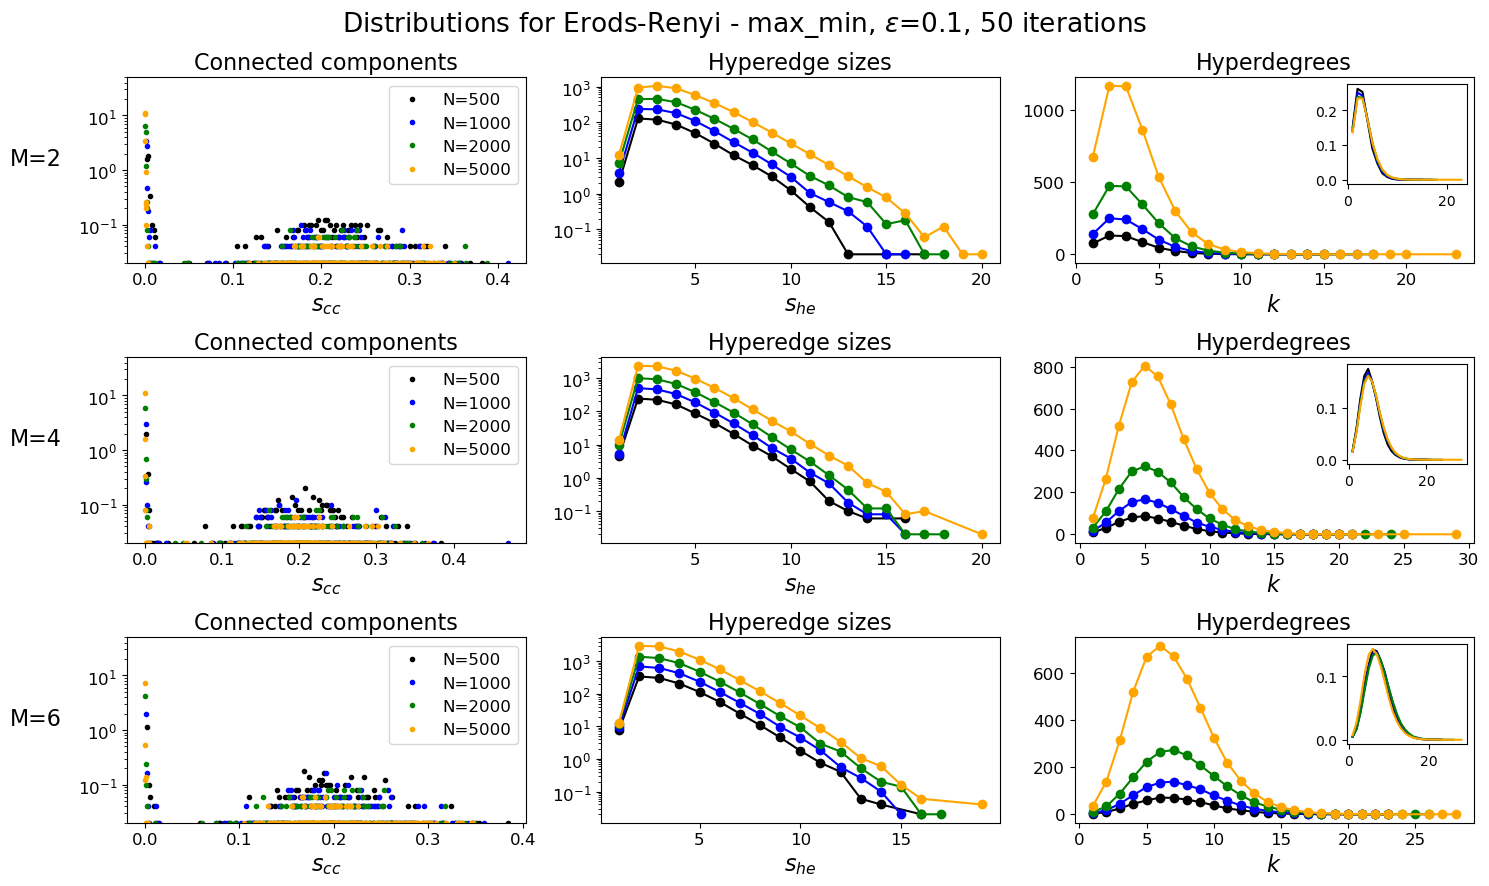

In [63]:
cond = 'max_min'
epsilon = 0.1
Ns = [500, 1000, 2000, 5000]
Ms = [2, 4, 6]

ncol = 3
fig, axs = plt.subplots(len(Ms), ncol, figsize=(15, 3*len(Ms)))
ttl_size = 16
lgd_size = 12
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N

for M in Ms:

    with open(f'../results/ER_M{M}_{cond}_distributions_eps_{epsilon}.pkl', 'rb') as f:
        results = pickle.load(f)

    sizes_cc = results['sizes_cc']
    sizes_he = results['sizes_he']
    sizes_hd = results['sizes_hd']
    n_iter = results['n_iterations']
    k_avg = results['k_avg']

    i = Ms.index(M)
    inset_ax = inset_axes(axs[i,2], width="30%", height=1.)
    for N,clr in zip(Ns, colors):
        
        x0 = [j/N for j in sorted(sizes_cc[N].keys())]
        y0 = [sizes_cc[N][j] for j in sorted(sizes_cc[N].keys())]
        axs[i,0].plot(x0, y0, color=clr, marker='o', markersize=3, linewidth=0, label=f'N={N}')
        axs[i,0].set_yscale('log')
        axs[i,0].set_ylim([1/n_iter, n_iter])
        axs[i,0].set_xlabel(r'$s_{cc}$', fontsize=ttl_size)
        axs[i,0].set_title('Connected components', rotation=0, fontsize=ttl_size)
        axs[i,0].legend(fontsize=lgd_size)

        x1 = sorted(sizes_he[N].keys())
        y1 = [sizes_he[N][x] for x in x1]
        axs[i,1].plot(x1, y1, color=clr, marker='o', label=f'N={N}')
        axs[i,1].set_yscale('log')        
        axs[i,1].set_xlabel(r'$s_{he}$', fontsize=ttl_size)
        axs[i,1].set_title('Hyperedge sizes', rotation=0, fontsize=ttl_size)

        x2 = sorted(sizes_hd[N].keys())
        y2 = [sizes_hd[N][x] for x in x2]
        axs[i,2].plot(x2, y2, color=clr, marker='o', label=f'N={N}')
        axs[i,2].set_xlabel(r'$k$', fontsize=ttl_size)
        axs[i,2].set_title('Hyperdegrees', rotation=0, fontsize=ttl_size)
        # inset plots
        y2_norm = [i/N for i in y2]
        inset_ax.plot(x2, y2_norm, color=clr)
        
        # print avg hyperdegree
        hd_avg = np.dot(x2, y2) / sum(y2)
        print(f'M={M}, N={N} ---> <k> = {hd_avg}')

        # set tick fontsize in all subplots
        for j in range(3):
            axs[i,j].tick_params(labelsize=12)
            
    axs[i,0].set_ylabel(f'M={M}', rotation=0, fontsize=ttl_size, labelpad=30)

plt.suptitle(rf'Distributions for Erods-Renyi - {cond}, $\epsilon$={epsilon}, {n_iter} iterations',
             fontsize=int(ttl_size*1.2))

plt.tight_layout()
plt.savefig(f'../figures/ER_{cond}_distributions_eps_{epsilon}.jpg', dpi=dpi)
plt.show()

# 2) Non-uniform ER

## 2.1) Results as a function of $\epsilon$

- number of connected components
- size of the largest connected component
- size of the second largest connected component
- number of hyperedges
- average hyperedge size
- max hyperedge size

    
Results averaged over 20 iterations.

Initial structure: ER hypergraph with with $\langle k_m \rangle = 3$ for each order of interaction $m = 2, 4, 6$.

In [7]:
from hypergraph_models import stratified_er_hypergraph

In [12]:
epsilons = np.linspace(0., 0.4, num=17)[1:]
cond = 'std'   # condition for agreement
ks_avg = [3, -1, 3, -1, 3]   # avg degree at each order (-1 = no hyperedges)
iterations = 20    # number of iterations for each epsilon

# auxiliary functions to parallelize computations
def get_results(N):
        
    # All below quantities are computed at the steady state, as a function of epsilon, averaged over 'iterations'
    ncc = []      # number of connected components
    scc1 = []     # size of the largest connected component
    scc2 = []     # size of the second largest connected component
    nhe = []      # number of hyperedges
    s_avg = []    # average hyperedge size
    s_max = []    # max hyperedge size
                  
    for eps in tqdm(epsilons):
    
        ncc_it = []
        scc1_it, scc2_it = [], []
        nhe_it = []
        s_avg_it, s_max_it = [], []
        
        for it in range(iterations):
            
            H = stratified_er_hypergraph(N, ks_avg, p_type='degree')
            H.cleanup()
            groups_0 = H.edges.members()
            
            Model = HAD_model(eps, groups_0)
            results = Model.simulate(condition=cond)
            opinions = results['opinions']
            groups = results['groups']
            
            # number of connected components and size of the two largest
            hedges = groups[-1]
            h = xgi.Hypergraph(hedges)
            # list of connected components
            cc = [j for j in xgi.connected_components(h)]
            ncc_it.append( len(cc) )                    
            scc = set([len(i) for i in cc])
            scc1_it.append( max(scc) / N )
            scc.remove(max(scc))
            if scc:
                scc2_it.append( max(scc) / N )
            else:
                scc2_it.append(0)
    
            # relative number of hyperedges
            nhe_it.append( len(groups[-1]) / len(groups_0) )
            
            # relative avg and std of hyperedge sizes
            sizes_end_it = [len(e) for e in groups[-1]]
            s_avg_it.append( np.mean(sizes_end_it) )
            s_max_it.append( np.max(sizes_end_it) )
            
        ncc.append(np.mean(ncc_it))
        scc1.append(np.mean(scc1_it))
        scc2.append(np.mean(scc2_it))
        nhe.append(np.mean(nhe_it))
        s_avg.append(np.mean(s_avg_it))
        s_max.append(np.mean(s_max_it))
        
    results = {
        'epsilons': epsilons,
        'ncc': ncc,
        'scc1': scc1,
        'scc2': scc2,
        'nhe': nhe,
        's_avg': s_avg,
        's_max': s_max
        }
    
    return results

In [13]:
Ns = [500, 1000, 2000, 5000]

p = Pool(processes=6)
results_ = p.map(get_results, Ns)

# save results
results = {Ns[i]: results_[i] for i in range(len(Ns))}

s_str = ''
it = 0
while it < len(ks_avg):
    if ks_avg[it]>0:
        s_str += f'{it+2}'
    it +=1

with open(f'../results/ER_s{s_str}_{cond}.pkl', 'wb') as fp:
        pickle.dump(results, fp)

  0%|                                                    | 0/16 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
100%|███████████████████████████████████████| 16/16 [7:45:14<00:00, 1744.66s/it]


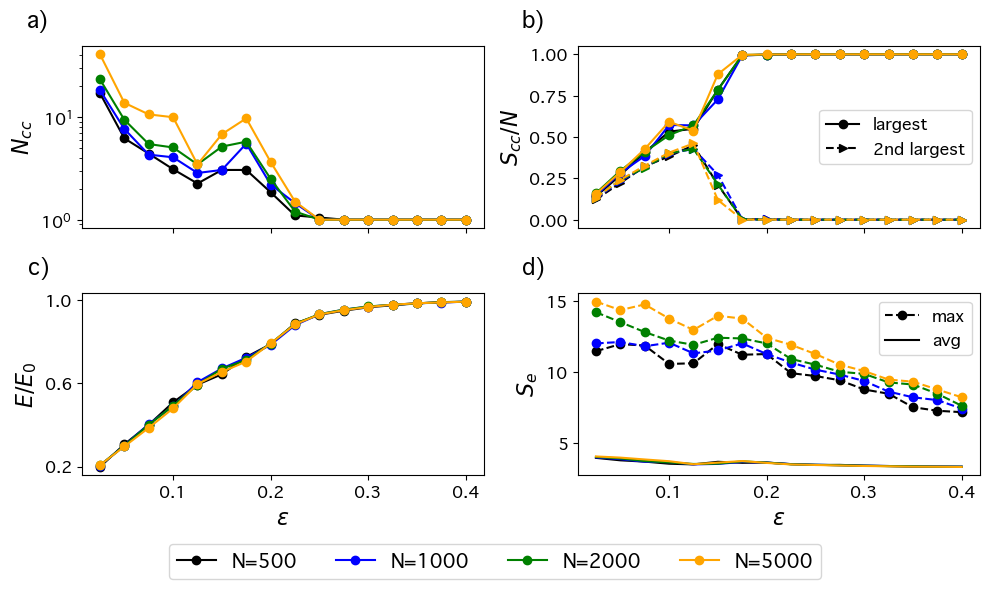

In [93]:
from itertools import product

s_str = '246'
cond = 'std'

with open(f'../results/ER_s{s_str}_{cond}.pkl', 'rb') as f:
    res = pickle.load(f)

colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N
lbls = ['largest', '2nd largest', 'avg', 'max']
lgd_size = 12
ttl_size = 16
# collect handles/labels for a global legend
legend_handles = []
legend_labels = []

Ns = [500, 1000, 2000, 5000]
nrows, ncols = 2,2
fig, axs = plt.subplots(nrows, ncols, sharex=True, figsize=(10,6.5))

for N,clr in zip(Ns, colors):

    res_dict = res[N]
    epsilons = res_dict['epsilons']
    ncc = res_dict['ncc']
    scc1 = res_dict['scc1']
    scc2 = res_dict['scc2']
    nhe = res_dict['nhe']
    s_avg = res_dict['s_avg']
    s_max = res_dict['s_max']

    line1, = axs[0,0].plot(epsilons, ncc, color=clr, marker='o', label=f'N={N}')
    legend_handles.append(line1)
    legend_labels.append(f'N={N}')
    axs[0,0].set_yscale('log')
    axs[0,0].set_ylabel(r'$N_{cc}$', fontsize=ttl_size)

    la0 = lbls[0] if N==Ns[0] else None
    la1 = lbls[1] if N==Ns[0] else None
    axs[0,1].plot(epsilons, scc1, color=clr, linestyle='-', marker='o', label=la0)
    axs[0,1].plot(epsilons, scc2, color=clr, linestyle='--', marker='>', label=la1)
    axs[0,1].set_ylabel(r'$S_{cc} / N$', fontsize=ttl_size)
    axs[0,1].legend(fontsize=lgd_size, loc=5)
        
    axs[1,0].plot(epsilons, nhe, color=clr, marker='o', label=f'N={N}')
    axs[1,0].set_ylabel(r'$E / E_0$', fontsize=ttl_size)
    axs[1,0].set_yticks([0.2,0.6,1.0])

    la2 = lbls[2] if N==Ns[0] else None
    la3 = lbls[3] if N==Ns[0] else None
    axs[1,1].plot(epsilons, s_max, label=la3, linestyle='--', marker='o', color=clr)
    axs[1,1].plot(epsilons, s_avg, label=la2, color=clr)
    axs[1,1].set_ylabel(r'$S_e$', fontsize=ttl_size)
    axs[1,1].legend(fontsize=lgd_size)

    # set xlabel tick fontsize in all subplots
    for j in range(ncols):
        axs[nrows-1,j].set_xlabel(r'$\epsilon$', fontsize=ttl_size)
        for i in range(nrows):
            axs[i,j].tick_params(labelsize=12)

# Add subplot labels
lbls = ['a)','b)','c)','d)']
for (i,j),lbl in zip(product([0,1],[0,1]), lbls):
    axs[i,j].text(-0.08, 1.2, lbl, transform=axs[i,j].transAxes, 
                  fontsize=ttl_size, fontweight='bold', va='top', ha='right')

# Global legend below plot, centered
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=(0.5, 0.002),
           fontsize=14, ncol=len(Ns))

plt.tight_layout(rect=[0, 0.07, 1, 0.93])
plt.savefig(f'../figures/ER_s{s_str}_{cond}.jpg', dpi=dpi)
plt.show()

## 2.2) Various distributions for $\epsilon=0.1$

- distribution of sizes of connected components
- distribution of sizes of hypredges
- distribution of hyperedgrees

Results averaged over 50 iterations.
Initial structure: ER hypergraph with with $\langle k_m \rangle = 3$ for each order of interaction $m = 2, 4, 6$.

In [39]:
epsilon = 0.1
cond = 'max_min'   # condition for agreement
ks_avg = [3, -1, 3, -1, 3]   # avg degree at each order (-1 = no hyperedges)
iterations = 50    # number of iterations

# auxiliary functions to parallelize computations
def get_distributions(N):
    
    counts_cc = dict()
    counts_he = dict()
    counts_hd = dict()
    
    for it in tqdm(range(iterations)):
        H = stratified_er_hypergraph(N, ks_avg, p_type='degree')
        H.cleanup()
        groups_0 = H.edges.members()
        
        Model = HAD_model(epsilon, groups_0)
        results = Model.simulate(condition=cond)
        groups = results['groups']
        # hyperedges at the end of the simulation
        hedges = groups[-1]
        h = xgi.Hypergraph(hedges)
        
        # sizes of connected components
        scc = [len(i) for i in xgi.connected_components(h)]
        for s in sorted(scc):
            if s in counts_cc.keys():
                counts_cc[s]+=1
            else:
                counts_cc[s]=1

        # sizes of hyperedges
        she = [len(i) for i in h.edges.members()]
        for s in sorted(she):
            if s in counts_he.keys():
                counts_he[s]+=1
            else:
                counts_he[s]=1

        # hyperdegrees
        hds = h.nodes.degree.aslist()
        for deg in sorted(hds):
            if deg in counts_hd.keys():
                counts_hd[deg]+=1
            else:
                counts_hd[deg]=1
        
    sizes_cc = {s: c/iterations for s,c in counts_cc.items()}
    sizes_he = {s: c/iterations for s,c in counts_he.items()}
    sizes_hd = {d: c/iterations for d,c in counts_hd.items()}

    results = {
        'epsilon': epsilon,
        'n_iterations': iterations,
        'ks_avg': ks_avg,
        'sizes_cc': sizes_cc,
        'sizes_he': sizes_he,
        'sizes_hd': sizes_hd
        }
    
    return results

In [11]:
Ns = [500, 1000, 2000, 5000]

p = Pool(processes=6)
results_ = p.map(get_distributions, Ns)

# save results
results = {Ns[i]: results_[i] for i in range(len(Ns))}

s_str = ''
it = 0
while it < len(ks_avg):
    if ks_avg[it]>0:
        s_str += f'{it+2}'
    it +=1

with open(f'../results/ER_s{s_str}_{cond}_distributions_eps_{epsilon}.pkl', 'wb') as fp:
        pickle.dump(results, fp)

100%|████████████████████████████████████████| 50/50 [2:05:54<00:00, 151.08s/it]


N=500 ---> <k> = 5.054092982315756
N=1000 ---> <k> = 5.164692938587718
N=2000 ---> <k> = 5.26009600960096
N=5000 ---> <k> = 5.2706458904246585


/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_2484/1019551788.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


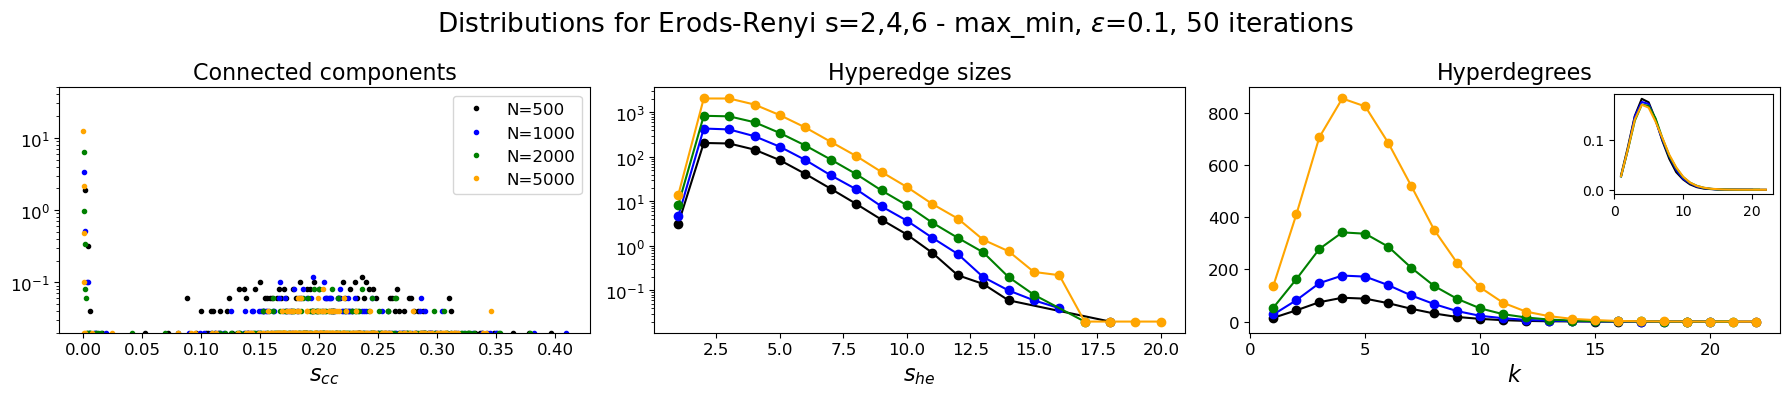

In [69]:
s_str = '246'
cond = 'max_min'
epsilon = 0.1
with open(f'../results/ER_s{s_str}_{cond}_distributions_eps_{epsilon}.pkl', 'rb') as f:
    res = pickle.load(f)

colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N
lbls = ['largest', '2nd largest', 'avg', 'max']
ttl_size = 16
lgd_size = 12

Ns = [500, 1000, 2000, 5000]
ncols = 3
fig, axs = plt.subplots(1,ncols, figsize=(18,4))
inset_ax = inset_axes(axs[2], width="30%", height=1.)

for N,clr in zip(Ns, colors):

    results = res[N]
    sizes_cc = results['sizes_cc']
    sizes_he = results['sizes_he']
    sizes_hd = results['sizes_hd']
    n_iter = results['n_iterations']
    ks_avg = results['ks_avg']
    
    x0 = [j/N for j in sorted(sizes_cc.keys())]
    y0 = [sizes_cc[j] for j in sorted(sizes_cc.keys())]
    axs[0].plot(x0, y0, color=clr, marker='o', markersize=3, linewidth=0, label=f'N={N}')
    axs[0].set_yscale('log')
    axs[0].set_ylim([1/n_iter, n_iter])
    axs[0].set_xlabel(r'$s_{cc}$', fontsize=ttl_size)
    axs[0].set_title('Connected components', rotation=0, fontsize=ttl_size)
    axs[0].legend(fontsize=lgd_size)

    x1 = sorted(sizes_he.keys())
    y1 = [sizes_he[x] for x in x1]
    axs[1].plot(x1, y1, color=clr, marker='o', label=f'N={N}')
    axs[1].set_yscale('log')
    axs[1].set_xlabel(r'$s_{he}$', fontsize=ttl_size)
    axs[1].set_title('Hyperedge sizes', rotation=0, fontsize=ttl_size)

    x2 = sorted(sizes_hd.keys())
    y2 = [sizes_hd[x] for x in x2]
    axs[2].plot(x2, y2, color=clr, marker='o', label=f'N={N}')
    axs[2].set_xlabel(r'$k$', fontsize=ttl_size)
    axs[2].set_title('Hyperdegrees', rotation=0, fontsize=ttl_size)
    # inset plots
    y2_norm = [i/N for i in y2]
    inset_ax.plot(x2, y2_norm, color=clr)

    # print avg hyperdegree
    hd_avg = np.dot(x2, y2) / sum(y2)
    print(f'N={N} ---> <k> = {hd_avg}')

    # set tick fontsize in all subplots
    for j in range(ncols):
        axs[j].tick_params(labelsize=12)

plt.suptitle(rf'Distributions for Erods-Renyi s={s_str[0]},{s_str[1]},{s_str[2]} - {cond}, $\epsilon$={epsilon}, {n_iter} iterations',
             fontsize=int(ttl_size*1.2))

plt.tight_layout()
plt.savefig(f'../figures/ER_s{s_str}_{cond}_distributions_eps_{epsilon}.jpg', dpi=dpi)
plt.show()

## Initial hyperdegree distribution of an ER hypergraph

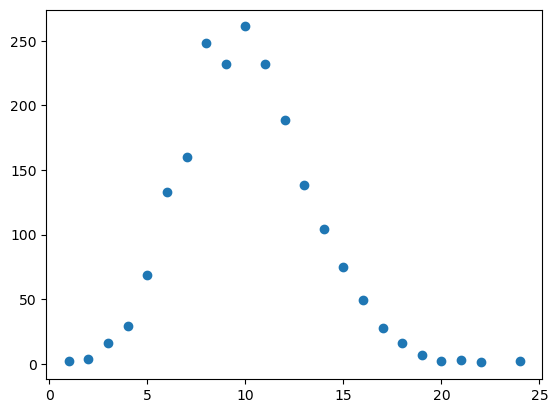

N=2000 ---> <k> = 10.084


In [85]:
M = 4
N = 2000
k_avg = 10
H = xgi.uniform_erdos_renyi_hypergraph(N, M, k_avg, p_type="degree")

# hyperdegrees
counts_hd = dict()
hds = H.nodes.degree.aslist()
for deg in sorted(hds):
    if deg in counts_hd.keys():
        counts_hd[deg]+=1
    else:
        counts_hd[deg]=1

x = sorted(counts_hd.keys())
y = [counts_hd[i] for i in x]

plt.plot(x,y, marker='o', lw=0)
plt.show()

# print avg hyperdegree
hd_avg = np.dot(x, y) / sum(y)
print(f'N={N} ---> <k> = {hd_avg}')